# Analyzing the Parker Solar Probe flybys

## 1. Modulus of the exit velocity, some features of Orbit #2

First, using the data available in the reports, we try to compute some of the properties of orbit #2. This is not enough to completely define the trajectory, but will give us information later on in the process:

In [ ]:
from astropy import units as u
from astropy.time import Time

from matplotlib import pyplot as plt

from poliastro.bodies import Earth, Mars, Jupiter, Sun
from poliastro.frames import Planes
from poliastro.twobody import Orbit

In [ ]:
T_ref = 150 * u.day
T_ref

<Quantity 150. d>

In [ ]:
from poliastro.bodies import Earth, Sun, Venus

In [ ]:
k = Sun.k
k

<Quantity 1.32712442e+20 m3 / s2>

In [ ]:
import numpy as np

$$ T = 2 \pi \sqrt{\frac{a^3}{\mu}} \Rightarrow a = \sqrt[3]{\frac{\mu T^2}{4 \pi^2}}$$

In [ ]:
a_ref = np.cbrt(k * T_ref**2 / (4 * np.pi**2)).to(u.km)
a_ref.to(u.au)

<Quantity 0.55249526 AU>

$$ \varepsilon = -\frac{\mu}{r} + \frac{v^2}{2} = -\frac{\mu}{2a} \Rightarrow v = +\sqrt{\frac{2\mu}{r} - \frac{\mu}{a}}$$

In [ ]:
energy_ref = (-k / (2 * a_ref)).to(u.J / u.kg)
energy_ref

<Quantity -8.02837549e+08 J / kg>

In [ ]:
from astropy.time import Time

from poliastro.ephem import Ephem
from poliastro.util import norm

In [ ]:
flyby_1_time = Time("2018-09-28", scale="tdb")
flyby_1_time

<Time object: scale='tdb' format='iso' value=2018-09-28 00:00:00.000>

In [ ]:
r_mag_ref = norm(Ephem.from_body(Venus, flyby_1_time).rv()[0].squeeze())
r_mag_ref.to(u.au)

<Quantity 0.72573132 AU>

In [ ]:
v_mag_ref = np.sqrt(2 * k / r_mag_ref - k / a_ref)
v_mag_ref.to(u.km / u.s)

<Quantity 28.96736351 km / s>

## 2. Lambert arc between #0 and #1

To compute the arrival velocity to Venus at flyby #1, we have the necessary data to solve the boundary value problem:

In [ ]:
d_launch = Time("2018-08-11", scale="tdb")
d_launch

<Time object: scale='tdb' format='iso' value=2018-08-11 00:00:00.000>

In [ ]:
r0, _ = Ephem.from_body(Earth, d_launch).rv()
r1, V = Ephem.from_body(Venus, flyby_1_time).rv()

In [ ]:
r0 = r0[0]
r1 = r1[0]
V = V[0]

In [ ]:
tof = flyby_1_time - d_launch

In [ ]:
from poliastro import iod

In [ ]:
v0, v1_pre = iod.lambert(Sun.k, r0, r1, tof.to(u.s))

In [ ]:
v0

<Quantity [ 9.59933726, 11.29855172,  2.92449333] km / s>

In [ ]:
v1_pre

<Quantity [-16.98082099,  23.30752839,   9.13129077] km / s>

In [ ]:
norm(v1_pre)

<Quantity 30.24846495 km / s>

## 3. Flyby #1 around Venus

We compute a flyby using poliastro with the default value of the entry angle, just to discover that the results do not match what we expected:

In [ ]:
from poliastro.threebody.flybys import compute_flyby

In [ ]:
V.to(u.km / u.day)

<Quantity [ 648499.73735241, 2695078.44750227, 1171563.7170508 ] km / d>

In [ ]:
h = 2548 * u.km

In [ ]:
d_flyby_1 = Venus.R + h
d_flyby_1.to(u.km)

<Quantity 8599.8 km>

In [ ]:
V_2_v_, delta_ = compute_flyby(v1_pre, V, Venus.k, d_flyby_1)

In [ ]:
norm(V_2_v_)

<Quantity 27.75533877 km / s>

## 4. Optimization

Now we will try to find the value of $\theta$ that satisfies our requirements:

In [ ]:
from poliastro.twobody import Orbit

In [ ]:
def func(theta):
    V_2_v, _ = compute_flyby(v1_pre, V, Venus.k, d_flyby_1, theta * u.rad)
    ss_1 = Orbit.from_vectors(Sun, r1, V_2_v, epoch=flyby_1_time)
    return (ss_1.period - T_ref).to(u.day).value

There are two solutions:

In [ ]:
from matplotlib import pyplot as plt

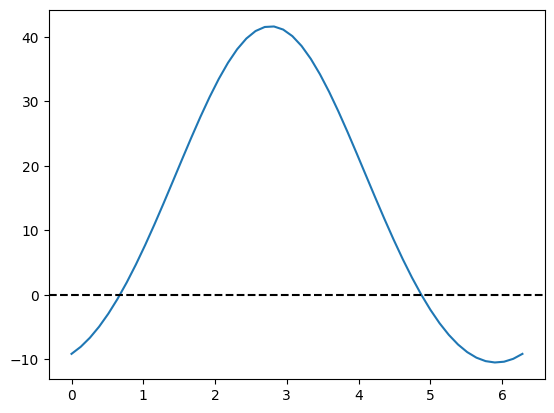

In [ ]:
theta_range = np.linspace(0, 2 * np.pi)
plt.plot(theta_range, [func(theta) for theta in theta_range])
plt.axhline(0, color="k", linestyle="dashed")

In [ ]:
func(0)

-9.142672330001218

In [ ]:
func(1)

7.098115439345711

In [ ]:
from scipy.optimize import brentq

In [ ]:
theta_opt_a = brentq(func, 0, 1) * u.rad
theta_opt_a.to(u.deg)

<Quantity 38.59870925 deg>

In [ ]:
theta_opt_b = brentq(func, 4, 5) * u.rad
theta_opt_b.to(u.deg)

<Quantity 279.34770004 deg>

In [ ]:
V_2_v_a, delta_a = compute_flyby(v1_pre, V[0], Venus.k, d_flyby_1, theta_opt_a)
V_2_v_b, delta_b = compute_flyby(v1_pre, V[0], Venus.k, d_flyby_1, theta_opt_b)

In [ ]:
norm(V_2_v_a)

<Quantity 29.97879854 km / s>

In [ ]:
norm(V_2_v_b)

<Quantity 29.49192479 km / s>

## 5. Exit orbit

And finally, we compute orbit #2 and check that the period is the expected one:

In [ ]:
ss01 = Orbit.from_vectors(Sun, r1, v1_pre, epoch=flyby_1_time)
ss01

0 x 1 AU x 18.8 deg (HCRS) orbit around Sun (☉) at epoch 2018-09-28 00:00:00.000 (TDB)

The two solutions have different inclinations, so we still have to find out which is the good one. We can do this by computing the inclination over the ecliptic - however, as the original data was in the International Celestial Reference Frame (ICRF), whose fundamental plane is parallel to the Earth equator of a reference epoch, we have to change the plane to the Earth **ecliptic**, which is what the original reports use:

In [ ]:
ss_1_a = Orbit.from_vectors(Sun, r1, V_2_v_a, epoch=flyby_1_time)
ss_1_a

0 x 1 AU x 24.0 deg (HCRS) orbit around Sun (☉) at epoch 2018-09-28 00:00:00.000 (TDB)

In [ ]:
ss_1_b = Orbit.from_vectors(Sun, r1, V_2_v_b, epoch=flyby_1_time)
ss_1_b

0 x 1 AU x 13.3 deg (HCRS) orbit around Sun (☉) at epoch 2018-09-28 00:00:00.000 (TDB)

In [ ]:
from poliastro.frames import Planes

In [ ]:
ss_1_a.change_plane(Planes.EARTH_ECLIPTIC)

0 x 1 AU x 3.4 deg (HeliocentricEclipticIAU76) orbit around Sun (☉) at epoch 2018-09-28 00:00:00.000 (TDB)

In [ ]:
ss_1_b.change_plane(Planes.EARTH_ECLIPTIC)

0 x 1 AU x 12.8 deg (HeliocentricEclipticIAU76) orbit around Sun (☉) at epoch 2018-09-28 00:00:00.000 (TDB)

Therefore, **the correct option is the first one**:

In [ ]:
ss_1_a.period.to(u.day)

<Quantity 158.75974993 d>

In [ ]:
ss_1_a.a

<Quantity 85839411.95296262 km>

And, finally, we plot the solution:

In [ ]:
from poliastro.plotting.static import StaticOrbitPlotter

frame = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)

frame.plot_body_orbit(Earth, d_launch)
frame.plot_body_orbit(Venus, flyby_1_time)
frame.plot(ss01, label="#0 to #1", color="C2")
frame.plot(ss_1_a, label="#1 to #2", color="C3")

ModuleNotFoundError: No module named 'poliastro.plotting.static'